# Task 1: Chunking and Indexing Strategies for Retrieval Analysis

This notebook evaluates the retrieval routine of the TextWave pipeline. This is a retrieval experiment, not an end-to-end answer generation experiment. The goal is to understand which preprocessing and retrieval choices surface chunks most effectively from the correct source article.

A retrieved chunk is treated as relevant if it comes from the article identified in the question's `ArticleFile` field. Because the question file stores article identifiers without the `.txt.clean` suffix, the notebook normalizes both corpus filenames and `ArticleFile` values to the same stem before scoring.

The notebook has two main parts:

1. **Chunking comparison** under brute-force retrieval  
2. **Index comparison** among Brute Force, HNSW, and LSH using the selected chunking strategy

The notebook isolates one design choice at a time.

- In the chunking comparison, the retrieval backend stays fixed and only the chunking strategy changes.
- In the index comparison, the chunking strategy is frozen and only the index changes.

In [1]:

import os
import sys
import glob
import re
import time
from pathlib import Path
from typing import Dict, List, Tuple, Iterable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import faiss
except Exception as exc:
    raise ImportError("faiss is required for this notebook.") from exc

from IPython.display import display

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("textwave exists:", (PROJECT_ROOT / "textwave").exists())

Project root: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main
textwave exists: True


In [3]:

from textwave.modules.extraction.preprocessing import DocumentProcessing
from textwave.modules.extraction.embedding import Embedding
from textwave.modules.retrieval.reranker import Reranker
from hnsw import FaissHNSW
from lsh import FaissLSH

In [4]:
# Notebook configuration
CORPUS_DIR = PROJECT_ROOT / "textwave" / "storage"
QUESTIONS_PATH = PROJECT_ROOT / "textwave" / "qa_resources" / "question.tsv"
RESULTS_DIR = PROJECT_ROOT / "analysis" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
TOP_K_VALUES = [1, 3, 5, 10]
PRIMARY_K = 5
RERANK_CANDIDATE_POOL = 50

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
TOP_K_VALUES = [1, 3, 5, 10]
PRIMARY_K = 5
RERANK_CANDIDATE_POOL = 50

# Slightly wider but still manageable grids.
FIXED_LENGTH_CONFIGS = [
    {"chunk_size": 75, "overlap_size": 0},
    {"chunk_size": 100, "overlap_size": 0},
    {"chunk_size": 150, "overlap_size": 10},
    {"chunk_size": 150, "overlap_size": 20},
    {"chunk_size": 200, "overlap_size": 20},
    {"chunk_size": 250, "overlap_size": 20},
    {"chunk_size": 300, "overlap_size": 30},
]

SENTENCE_CONFIGS = [
    {"num_sentences": 1, "overlap_size": 0},
    {"num_sentences": 2, "overlap_size": 0},
    {"num_sentences": 3, "overlap_size": 0},
    {"num_sentences": 3, "overlap_size": 1},
    {"num_sentences": 4, "overlap_size": 1},
    {"num_sentences": 5, "overlap_size": 1},
]

# Slightly wider ANN grids, still small enough for a notebook study.
HNSW_CONFIGS = [
    {"M": 16, "efConstruction": 40, "metric": "euclidean"},
    {"M": 16, "efConstruction": 80, "metric": "euclidean"},
    {"M": 32, "efConstruction": 80, "metric": "euclidean"},
    {"M": 32, "efConstruction": 120, "metric": "euclidean"},
]

LSH_CONFIGS = [
    {"nbits": 64},
    {"nbits": 128},
    {"nbits": 256},
]

# Later, after inspection, fill these choices explicitly.
SELECTED_CHUNKING = None
SELECTED_INDEX = None

print("Corpus directory:", CORPUS_DIR)
print("Questions path:", QUESTIONS_PATH)
print("Fixed-length configs:", len(FIXED_LENGTH_CONFIGS))
print("Sentence configs:", len(SENTENCE_CONFIGS))
print("HNSW configs:", len(HNSW_CONFIGS))
print("LSH configs:", len(LSH_CONFIGS))

Corpus directory: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\textwave\storage
Questions path: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\textwave\qa_resources\question.tsv
Fixed-length configs: 7
Sentence configs: 6
HNSW configs: 4
LSH configs: 3


## System components used in this notebook

This notebook evaluates the retrieval side of the RAG pipeline. The goal is to keep the experiments close to the actual system design while varying only the components under study: chunking, indexing, and reranking. The notebook uses `DocumentProcessing` to create alternative chunk boundaries, `Embedding('all-MiniLM-L6-v2')` to map both chunks and questions into the same dense vector space, FAISS-based exact and approximate indexes to compare retrieval backends, and the project `Reranker` class to test reranking strategies. Keeping these components separate makes the comparisons more interpretable.

The notebook therefore mirrors the structure of the full retrieval pipeline: first define the retrieval units through chunking, then encode them into embeddings, then compare exact and approximate nearest-neighbor search, and finally test whether reranking improves the ordering of the retrieved chunks before later generation tasks.

## Load and inspect the evaluation questions

The retrieval experiments in this notebook are driven by the provided `question.tsv` file. This table defines the evaluation set: each row contains a question and, through the associated article identifier, the source document that should be considered relevant for retrieval. Before running any retrieval pipeline, it is useful to inspect the structure of this file, confirm the available columns, and verify the number of questions that will be evaluated. This gives us the basic unit of analysis for all later comparisons.

In [5]:
# Load the question set
questions_df = pd.read_csv(QUESTIONS_PATH, sep="\t")
print("Question columns:", list(questions_df.columns))
display(questions_df.head())
print("Number of questions:", len(questions_df))

Question columns: ['ArticleTitle', 'Question', 'Answer', 'DifficultyFromQuestioner', 'DifficultyFromAnswerer', 'ArticleFile']


,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile
0,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,yes,easy,easy,S08_set3_a4
1,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,easy,S08_set3_a4
2,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,yes,easy,medium,S08_set3_a4
3,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,easy,S08_set3_a4
4,Abraham_Lincoln,Did his mother die of pneumonia?,no,easy,medium,S08_set3_a4


Number of questions: 1051


The dataset contains 1051 questions and includes the article title, question text, gold answer, difficulty labels from both the questioner and answerer, and the source article file. This inspection step is important because it confirms that the evaluation data is aligned with the retrieval pipeline and also highlights small formatting variations in the answers, such as differences in capitalization.

## Detect the gold-answer field for answer-bearing retrieval diagnostics

In addition to article-level relevance, this notebook also evaluates whether retrieved chunks actually contain the expected answer text. To do that, we first need to determine whether the question file includes a gold-answer column. Here we identify the gold answer as the content of the 'Answer' column: it will be used to compute answer-bearing ``Recall@k``, which measures the proportion of questions for which at least one of the top-k retrieved chunks contains the gold answer string. This metric is useful because retrieving a chunk from the correct article is not always sufficient; a system is more helpful when the retrieved context also includes the specific evidence needed to answer the question.

In [6]:
# Identify the gold-answer column for answer-bearing retrieval diagnostics
ANSWER_COLUMN_CANDIDATES = [
    "Answer"
]

ANSWER_COLUMN = next((col for col in ANSWER_COLUMN_CANDIDATES if col in questions_df.columns), None)
if ANSWER_COLUMN is None:
    print("No answer column found in question.tsv. Answer-bearing Recall@k will be reported as NaN.")
else:
    print("Using gold-answer column for answer-bearing retrieval diagnostics:", ANSWER_COLUMN)


Using gold-answer column for answer-bearing retrieval diagnostics: Answer


## Load the corpus and verify alignment with the question set

Retrieval can only be evaluated correctly if the corpus files referenced by the questions are actually present in the local collection. This step loads all available corpus documents, normalizes file identifiers so that corpus filenames and `ArticleFile` entries are comparable, and then checks whether every question points to an available source article. Conceptually, this is an integrity check: it ensures that the evaluation set and the document collection are aligned before chunking, indexing, and retrieval begin.

In [7]:
# Load available corpus files and verify coverage
corpus_files = sorted(CORPUS_DIR.glob("*.clean"))
corpus_names = [path.name for path in corpus_files]

def normalize_article_id(value: str) -> str:
    value = Path(str(value)).name
    for suffix in [".txt.clean", ".clean", ".txt"]:
        if value.endswith(suffix):
            value = value[: -len(suffix)]
    return value

available_article_ids = {normalize_article_id(path.name) for path in corpus_files}
question_article_ids = set(questions_df["ArticleFile"].astype(str).map(normalize_article_id))

missing_from_corpus = sorted(question_article_ids - available_article_ids)

print("Number of corpus files:", len(corpus_files))
print("Sample corpus files:", corpus_names[:5])
print("Missing ArticleFile references:", len(missing_from_corpus))
if missing_from_corpus:
    print("Missing examples:", missing_from_corpus[:10])

Number of corpus files: 150
Sample corpus files: ['S08_set1_a1.txt.clean', 'S08_set1_a10.txt.clean', 'S08_set1_a2.txt.clean', 'S08_set1_a3.txt.clean', 'S08_set1_a4.txt.clean']
Missing ArticleFile references: 1
Missing examples: ['nan']


In [8]:
# Rows where ArticleFile is truly missing
missing_articlefile_rows = questions_df[questions_df["ArticleFile"].isna()]
display(missing_articlefile_rows)
print("Rows with ArticleFile = NaN:", len(missing_articlefile_rows))

,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile
573,Gerald_Ford,Was Ford active about Vietnamese affairs?,No,NaN,NaN,NaN
574,\n,hard,hard,S08_set3_a10,NaN,NaN


Rows with ArticleFile = NaN: 2


In [9]:
empty_articlefile_rows = questions_df[
    questions_df["ArticleFile"].notna() &
    (questions_df["ArticleFile"].astype(str).str.strip() == "")
]
display(empty_articlefile_rows)
print("Rows with empty ArticleFile:", len(empty_articlefile_rows))

,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile


Rows with empty ArticleFile: 0


In [10]:
problem_articlefile_rows = questions_df[
    questions_df["ArticleFile"].isna() |
    (questions_df["ArticleFile"].astype(str).str.strip() == "")
]
display(problem_articlefile_rows)
print("Total problematic ArticleFile rows:", len(problem_articlefile_rows))

,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile
573,Gerald_Ford,Was Ford active about Vietnamese affairs?,No,NaN,NaN,NaN
574,\n,hard,hard,S08_set3_a10,NaN,NaN


Total problematic ArticleFile rows: 2


This inspection shows that the storage folder contains 150 cleaned source files. During validation of the `ArticleFile` field, we found a small data-quality issue: although only one missing reference is first detected at a high level, a closer row-level check reveals two problematic rows with `ArticleFile = NaN`. These rows appear to come from a malformed or misaligned entry in the question table, since the second row does not look like a valid question record. Because retrieval evaluation depends on linking each question to its source article, these problematic rows should be excluded or cleaned before computing metrics, so they do not introduce noise or unfairly penalize the system.

## Initialize the retrieval components and validate chunk construction

Before running the full experiments, it is useful to perform a small sanity check on the core retrieval components. In this step, we initialize the project chunking and embedding modules, define a helper function that converts corpus documents into a structured chunk table, and records provenance for every chunk, including its source article, position within the article, chunking strategy, and length. This makes the later analyses easier to interpret because each retrieved chunk can be traced back to its origin.

The final part of this block applies one example chunking configuration and inspects the resulting chunk table. This confirms that chunking is producing reasonable outputs, that article identifiers are being carried forward correctly, and that chunk counts and average chunk lengths look plausible before the notebook moves on to systematic comparisons across chunking strategies.

In [11]:

processor = DocumentProcessing()
embedder = Embedding(EMBEDDING_MODEL_NAME)
print("Loaded chunker and embedder.")

Loaded chunker and embedder.


In [12]:
# Build a chunk table with provenance
def build_chunk_table(
    corpus_paths: Iterable[Path],
    strategy: str,
    parameters: Dict[str, int],
    processor: DocumentProcessing,
) -> pd.DataFrame:
    rows = []

    for file_path in corpus_paths:
        article_file = file_path.name
        article_id = normalize_article_id(article_file)

        if strategy == "fixed-length":
            chunks = processor.fixed_length_chunking(
                str(file_path),
                chunk_size=parameters["chunk_size"],
                overlap_size=parameters.get("overlap_size", 0),
            )
        elif strategy == "sentence":
            chunks = processor.sentence_chunking(
                str(file_path),
                num_sentences=parameters["num_sentences"],
                overlap_size=parameters.get("overlap_size", 0),
            )
        else:
            raise ValueError(f"Unsupported chunking strategy: {strategy}")

        for chunk_order, chunk_text in enumerate(chunks):
            rows.append(
                {
                    "chunk_id": len(rows),
                    "article_file": article_file,
                    "article_id": article_id,
                    "chunk_text": chunk_text,
                    "chunk_order": chunk_order,
                    "chunking_strategy": strategy,
                    "chunking_parameters": dict(parameters),
                    "chunk_length_chars": len(chunk_text),
                }
            )

    chunk_df = pd.DataFrame(rows)
    if not chunk_df.empty:
        chunk_df["chunk_id"] = np.arange(len(chunk_df))
    return chunk_df

In [13]:
# Quick sanity check on one chunking configuration
example_chunk_df = build_chunk_table(
    corpus_paths=corpus_files,
    strategy="fixed-length",
    parameters={"chunk_size": 150, "overlap_size": 20},
    processor=processor,
)

print("Example chunk count:", len(example_chunk_df))
display(example_chunk_df.head())
display(
    example_chunk_df.groupby("article_id")
    .size()
    .reset_index(name="num_chunks")
    .sort_values("num_chunks", ascending=False)
    .head()
)
print("Average chunk length:", round(example_chunk_df["chunk_length_chars"].mean(), 2))

Example chunk count: 33306


,chunk_id,article_file,article_id,chunk_text,chunk_order,chunking_strategy,chunking_parameters,chunk_length_chars
0,0,S08_set1_a1.txt.clean,S08_set1_a1,kangaroo A kangaroo is a marsupial from the fa...,0,fixed-length,"{'chunk_size': 150, 'overlap_size': 20}",150
1,1,S08_set1_a1.txt.clean,S08_set1_a1,to describe the largest species from this fami...,1,fixed-length,"{'chunk_size': 150, 'overlap_size': 20}",150
2,2,S08_set1_a1.txt.clean,S08_set1_a1,aroo of the Macropus genus. The family also in...,2,fixed-length,"{'chunk_size': 150, 'overlap_size': 20}",150
3,3,S08_set1_a1.txt.clean,S08_set1_a1,"pademelons and the Quokka, some 63 living spec...",3,fixed-length,"{'chunk_size': 150, 'overlap_size': 20}",150
4,4,S08_set1_a1.txt.clean,S08_set1_a1,acropods are found in Australia and New Guinea...,4,fixed-length,"{'chunk_size': 150, 'overlap_size': 20}",150


,article_id,num_chunks
27,S08_set3_a7,583
42,S09_set1_a2,563
6,S08_set1_a6,527
14,S08_set2_a4,511
123,S10_set4_a3,489


Average chunk length: 149.74


These results confirm that the retrieval pipeline is constructing chunks correctly before any indexing or ranking is performed. With the example configuration of fixed-length chunking using `chunk_size = 150` and `overlap_size = 20`, the corpus is split into 33306 chunks, which gives the retriever many small candidate passages to search over. The preview shows that each chunk keeps its article identifier, order, and metadata, which is important for tracing retrieval results back to their source documents during evaluation. The average chunk length of 149.74 characters is very close to the target size, indicating that the chunker is behaving as expected. The per-article counts also show substantial variation across documents, meaning longer articles naturally contribute many more chunks to the index. This matters because smaller chunks can improve precision by isolating relevant evidence more tightly, but they also increase the size of the search space and may fragment context across multiple chunks.


## Embedding the corpus and defining retrieval representations

Once documents have been split into chunks, the next step is to represent both chunks and questions in a form that supports retrieval. In this notebook, that representation is a dense embedding vector: each chunk is mapped into a shared semantic vector space, and each question is encoded into the same space so that similarity search can compare them directly. This is the bridge between raw text and retrieval: instead of searching over strings, the system searches over vector representations of meaning.

This section therefore has two purposes. First, it creates the vector representations that will be used throughout the rest of the notebook for chunk retrieval and question matching. Second, it defines the evaluation metrics that determine whether retrieval is good. These metrics capture different aspects of retrieval quality: whether at least one relevant chunk appears in the top results, how early relevant chunks are ranked, how clean the top-k list is, whether retrieved chunks actually contain the expected answer text, and, for approximate indexes, how closely their retrieved neighbors match the exact brute-force baseline. Together, these representations and metrics establish the common evaluation framework used for all later comparisons of chunking, indexing, and reranking strategies.

In [14]:
# Embedding helpers
def encode_texts(texts: List[str], embedder: Embedding) -> np.ndarray:
    vectors = embedder.encode(texts)
    vectors = np.asarray(vectors, dtype=np.float32)
    if vectors.ndim == 1:
        vectors = vectors.reshape(1, -1)
    return vectors

def attach_embeddings(chunk_df: pd.DataFrame, embedder: Embedding) -> np.ndarray:
    if chunk_df.empty:
        raise ValueError("Chunk dataframe is empty.")
    return encode_texts(chunk_df["chunk_text"].tolist(), embedder)

In [15]:

example_embeddings = attach_embeddings(example_chunk_df, embedder)
print("Embedding matrix shape:", example_embeddings.shape)
print("Embedding dtype:", example_embeddings.dtype)

Embedding matrix shape: (33306, 384)
Embedding dtype: float32


In [16]:
# Query embedding helper
def add_query_embeddings(questions: pd.DataFrame, embedder: Embedding, question_col: str = "Question") -> pd.DataFrame:
    questions = questions.copy()
    query_embeddings = encode_texts(questions[question_col].astype(str).tolist(), embedder)
    questions["query_embedding"] = list(query_embeddings)
    questions["article_id_norm"] = questions["ArticleFile"].astype(str).map(normalize_article_id)
    return questions

questions_with_embeddings = add_query_embeddings(questions_df, embedder)
display(questions_with_embeddings.head())

,ArticleTitle,Question,Answer,DifficultyFromQuestioner,DifficultyFromAnswerer,ArticleFile,query_embedding,article_id_norm
0,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,yes,easy,easy,S08_set3_a4,"[-0.0037567802, 0.037963822, -0.031820443, -0....",S08_set3_a4
1,Abraham_Lincoln,Was Abraham Lincoln the sixteenth President of...,Yes.,easy,easy,S08_set3_a4,"[-0.0037567802, 0.037963822, -0.031820443, -0....",S08_set3_a4
2,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,yes,easy,medium,S08_set3_a4,"[-0.032314997, -0.009452126, -0.109447256, -0....",S08_set3_a4
3,Abraham_Lincoln,Did Lincoln sign the National Banking Act of 1...,Yes.,easy,easy,S08_set3_a4,"[-0.032314997, -0.009452126, -0.109447256, -0....",S08_set3_a4
4,Abraham_Lincoln,Did his mother die of pneumonia?,no,easy,medium,S08_set3_a4,"[0.008822218, 0.025887419, -0.018949647, 0.071...",S08_set3_a4


In [17]:
# Retrieval metrics
def binary_relevance(retrieved_article_ids: List[str], target_article_id: str) -> List[int]:
    return [1 if article_id == target_article_id else 0 for article_id in retrieved_article_ids]


def hit_at_k(relevances: List[int], k: int) -> float:
    if not relevances:
        return 0.0
    return float(any(relevances[:k]))


def recall_at_k(relevances: List[int], total_relevant: int, k: int) -> float:
    if total_relevant <= 0:
        return 0.0
    return float(sum(relevances[:k]) / total_relevant)


def precision_at_k(relevances: List[int], k: int) -> float:
    if k <= 0:
        return 0.0
    return float(sum(relevances[:k]) / k)


def average_precision_at_k(relevances: List[int], total_relevant: int, k: int) -> float:
    cutoff = min(k, len(relevances))
    denom = min(total_relevant, k)
    if cutoff <= 0 or denom <= 0:
        return 0.0

    num_hits = 0
    precision_sum = 0.0
    for rank, rel in enumerate(relevances[:cutoff], start=1):
        if rel:
            num_hits += 1
            precision_sum += num_hits / rank
    return float(precision_sum / denom)


def reciprocal_rank(relevances: List[int]) -> float:
    for idx, rel in enumerate(relevances, start=1):
        if rel == 1:
            return 1.0 / idx
    return 0.0


def dcg_at_k(relevances: List[int], k: int) -> float:
    gains = np.asarray(relevances[:k], dtype=float)
    if gains.size == 0:
        return 0.0
    discounts = np.log2(np.arange(2, gains.size + 2))
    return float(np.sum(gains / discounts))


def ndcg_at_k(relevances: List[int], total_relevant: int, k: int) -> float:
    ideal = [1] * min(total_relevant, k)
    ideal_dcg = dcg_at_k(ideal, k)
    if ideal_dcg == 0:
        return 0.0
    return dcg_at_k(relevances, k) / ideal_dcg


def normalize_text_for_match(text: str) -> str:
    if text is None:
        return ""
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text


def parse_gold_answer_strings(raw_value) -> List[str]:
    if raw_value is None:
        return []
    try:
        if pd.isna(raw_value):
            return []
    except Exception:
        pass

    raw_text = str(raw_value).strip()
    if not raw_text:
        return []

    parts = re.split(r"\s*\|\|\s*|\s*\|\s*|\s*;\s*", raw_text)
    answers = [normalize_text_for_match(part) for part in parts if normalize_text_for_match(part)]
    return answers or [normalize_text_for_match(raw_text)]


def answer_recall_at_k(retrieved_texts: List[str], gold_answers: List[str], k: int) -> float:
    if not gold_answers:
        return np.nan

    normalized_chunks = [
        normalize_text_for_match(text) for text in retrieved_texts[:k]
    ]

    normalized_answers = [
        normalize_text_for_match(answer)
        for answer in gold_answers
        if answer is not None and str(answer).strip() != ""
    ]

    if not normalized_answers:
        return np.nan

    for answer in normalized_answers:
        if any(answer in chunk for chunk in normalized_chunks):
            return 1.0
    return 0.0


def ann_recall_at_k(retrieved_indices: List[int], exact_indices: List[int], k: int) -> float:
    if k <= 0:
        return 0.0
    exact_top_k = [idx for idx in exact_indices[:k] if idx >= 0]
    if not exact_top_k:
        return 0.0
    approx_top_k = set(idx for idx in retrieved_indices[:k] if idx >= 0)
    overlap = sum(1 for idx in exact_top_k if idx in approx_top_k)
    return float(overlap / len(exact_top_k))


## Why these metrics

Here, "top-k" refers to the first k chunks returned by the retriever for a given question, ranked from most to least relevant according to the retrieval system. Evaluating the top-k results is important because, in a retrieval-augmented pipeline, these are the chunks most likely to be passed forward as context for answer generation.

- **Hit@k** asks whether at least one chunk from the correct article appears in the top-k results. This is a useful proxy for whether the generator would receive relevant context.
- **Recall@k** measures how many of the article's relevant chunks were recovered in the top-k. Because the number of chunks per article varies with the chunking strategy, this metric is informative but should not be interpreted in isolation.
- **Precision@k** measures how clean the top-*k* list is, which helps distinguish broad retrieval coverage from top-rank noise.
- **MAP@k** rewards systems that rank multiple relevant chunks well throughout the top-*k*, not only the very first hit.
- **Answer-bearing Recall@k** asks a stricter question: does any top-*k* chunk contain the gold answer string? This is a useful bridge between retrieval quality and downstream generation readiness.
- **MRR** rewards systems that place the first relevant chunk earlier.
- **nDCG@10** rewards systems that place multiple relevant chunks near the top of the ranking.

``nDCG@10`` requires a bit more of explanation, as it is a type of metric that we have not used in earlier projects. It stands for Normalized Discounted Cumulative Gain (at 10), and evaluates the overall quality of the top-10 ranking, not just whether a relevant chunk appears somewhere in it. For a query with relevance labels $rel_i$ at ranks $i=1,...,10$, the discounted cumulative gain is defined as
  
$$
DCG@10=\sum_{i=1}^{10}\frac{2^{rel_i}-1}{\log_2(i+1)}.
$$

This is then normalized by the ideal value $IDCG@10$, which is the maximum possible $DCG@10$ for that same query if the relevant items were ordered perfectly. The final score is

$$
nDCG@10=\frac{DCG@10}{IDCG@10}.
$$

In our setting, where relevance is typically binary, this means the metric gives credit for retrieving relevant chunks, but gives more credit when they appear earlier in the ranking and when several of them are concentrated near the top. It is therefore a measure of how well the retriever organizes the whole top-ranked list, not just whether it finds one relevant hit.


## Exact retrieval baseline and unified evaluation framework

This section establishes the retrieval baseline and the common evaluation logic used throughout the notebook. The baseline search method is brute-force nearest-neighbor retrieval over chunk embeddings, implemented with a flat FAISS index. Conceptually, this is the simplest and most faithful way to search the embedding space: every query embedding is compared against all chunk embeddings, so the returned neighbors serve as the exact reference point for later comparisons with approximate indexes. Because it does not rely on approximation, this baseline is also the natural standard against which ANN behavior can be measured.

The rest of this section builds an evaluation setup for all retrieval experiments, using shared helper functions that do the same three steps every time: search the index, recover the retrieved chunks and their metadata, and compute the same set of evaluation metrics. The metrics are designed to answer different but complementary questions: whether relevant chunks are retrieved at all, how high they appear in the ranking, how accurate the top results are, whether the retrieved text actually contains the expected answer, and, for approximate methods, how closely their results match the brute-force reference.

In [18]:
# Brute force exact retrieval helper (same flat-FAISS pattern as app.py)
def build_bruteforce_index(embeddings: np.ndarray):
    index = faiss.IndexFlatL2(embeddings.shape[1])
    index.add(np.asarray(embeddings, dtype=np.float32))
    return index

def search_bruteforce(index, query_vector: np.ndarray, top_k: int):
    query_vector = np.asarray(query_vector, dtype=np.float32).reshape(1, -1)
    distances, indices = index.search(query_vector, top_k)
    return distances[0], indices[0]

In [19]:
# Generic evaluation harness
def evaluate_ranked_results(
    retrieved_chunk_rows: pd.DataFrame,
    target_article_id: str,
    total_relevant: int,
    top_k_values: List[int] = TOP_K_VALUES,
    gold_answer_texts: Optional[List[str]] = None,
) -> Dict[str, float]:
    retrieved_article_ids = retrieved_chunk_rows["article_id"].tolist()
    relevances = binary_relevance(retrieved_article_ids, target_article_id)
    retrieved_texts = retrieved_chunk_rows.get("chunk_text", pd.Series(dtype=str)).fillna("").astype(str).tolist()

    metrics = {}
    for k in top_k_values:
        metrics[f"Hit@{k}"] = hit_at_k(relevances, k)
        metrics[f"Recall@{k}"] = recall_at_k(relevances, total_relevant, k)
        metrics[f"Precision@{k}"] = precision_at_k(relevances, k)
        metrics[f"MAP@{k}"] = average_precision_at_k(relevances, total_relevant, k)
        metrics[f"AnswerRecall@{k}"] = answer_recall_at_k(retrieved_texts, gold_answer_texts or [], k)

    metrics["MRR"] = reciprocal_rank(relevances)
    metrics["nDCG@10"] = ndcg_at_k(relevances, total_relevant, 10)
    return metrics


def summarize_per_query_results(per_query_results: List[Dict]) -> pd.DataFrame:
    result_df = pd.DataFrame(per_query_results)
    metric_cols = [
        col
        for col in result_df.columns
        if any(
            col.startswith(prefix)
            for prefix in ["Hit@", "Recall@", "Precision@", "MAP@", "AnswerRecall@", "ANNRecall@", "MRR", "nDCG"]
        )
    ]
    summary = result_df[metric_cols].mean(numeric_only=True).to_frame(name="value").reset_index()
    summary.columns = ["metric", "value"]
    return summary


In [20]:
# Backend-specific search helpers
def get_question_gold_answers(row: pd.Series) -> List[str]:
    if ANSWER_COLUMN is None:
        return []
    return parse_gold_answer_strings(row.get(ANSWER_COLUMN))


def get_underlying_faiss_index(index_obj):
    return index_obj.index if hasattr(index_obj, "index") else index_obj


def estimate_index_size_bytes(index_obj) -> Optional[int]:
    try:
        raw_index = get_underlying_faiss_index(index_obj)
        serialized = faiss.serialize_index(raw_index)
        return int(np.asarray(serialized).nbytes)
    except Exception:
        try:
            return int(sys.getsizeof(index_obj))
        except Exception:
            return None


def search_with_metadata(index_obj, backend_name: str, query_vector: np.ndarray, top_k: int, chunk_df: pd.DataFrame):
    query_vector = np.asarray(query_vector, dtype=np.float32).reshape(1, -1)

    if backend_name == "bruteforce":
        distances, indices = search_bruteforce(index_obj, query_vector, top_k)

    elif backend_name == "hnsw":
        distances, indices = index_obj.index.search(query_vector, top_k)
        distances, indices = distances[0], indices[0]

    elif backend_name == "lsh":
        distances, indices = index_obj.index.search(query_vector, top_k)
        distances, indices = distances[0], indices[0]

    else:
        raise ValueError(f"Unknown backend: {backend_name}")

    valid_indices = [int(i) for i in indices if int(i) >= 0]
    retrieved_rows = chunk_df.iloc[valid_indices].copy().reset_index(drop=True)
    return distances, valid_indices, retrieved_rows


def evaluate_retrieval_backend(
    questions: pd.DataFrame,
    chunk_df: pd.DataFrame,
    backend_name: str,
    backend_obj,
    top_k: int,
    top_k_values: List[int] = TOP_K_VALUES,
    reference_backend_obj=None,
    reference_backend_name: str = "bruteforce",
):
    per_query_results = []
    query_times = []

    relevant_counts = chunk_df["article_id"].value_counts().to_dict()
    reference_backend_obj = reference_backend_obj or backend_obj
    reference_backend_name = reference_backend_name or backend_name

    for _, row in questions.iterrows():
        target_article_id = row["article_id_norm"]
        query_vector = row["query_embedding"]
        gold_answers = get_question_gold_answers(row)

        start = time.perf_counter()
        _, retrieved_indices, retrieved_rows = search_with_metadata(
            backend_obj, backend_name, query_vector, top_k=top_k, chunk_df=chunk_df
        )
        query_times.append(time.perf_counter() - start)

        if reference_backend_obj is backend_obj and reference_backend_name == backend_name:
            reference_indices = retrieved_indices
        else:
            _, reference_indices, _ = search_with_metadata(
                reference_backend_obj,
                reference_backend_name,
                query_vector,
                top_k=top_k,
                chunk_df=chunk_df,
            )

        total_relevant = int(relevant_counts.get(target_article_id, 0))
        metrics = evaluate_ranked_results(
            retrieved_chunk_rows=retrieved_rows,
            target_article_id=target_article_id,
            total_relevant=total_relevant,
            top_k_values=top_k_values,
            gold_answer_texts=gold_answers,
        )
        for k in top_k_values:
            metrics[f"ANNRecall@{k}"] = ann_recall_at_k(retrieved_indices, reference_indices, k)

        per_query_results.append(
            {
                "Question": row["Question"],
                "target_article_id": target_article_id,
                **metrics,
            }
        )

    per_query_df = pd.DataFrame(per_query_results)
    summary = per_query_df.mean(numeric_only=True).to_dict()
    total_query_time = float(np.sum(query_times))
    summary["mean_query_time_sec"] = float(np.mean(query_times)) if query_times else np.nan
    summary["p95_query_time_sec"] = float(np.percentile(query_times, 95)) if query_times else np.nan
    summary["throughput_qps"] = float(len(query_times) / total_query_time) if total_query_time > 0 else np.nan
    return per_query_df, summary


# Part A: Compare chunking strategies under brute-force retrieval

This first experiment asks the following question: if the retrieval backend is held constant, how much does chunking affect retrieval quality? To answer that, this section isolates chunking as the only changing design choice. The corpus, the question set, the embedding model, the relevance definition, and the search backend all remain fixed, so differences in performance can be interpreted as consequences of how the documents were segmented rather than of changes elsewhere in the pipeline. This follows the notebook's broader evaluation protocol of varying one component at a time.

Chunking determines the basic retrieval unit. A long article is not retrieved as one block; instead, it is split into smaller pieces, and retrieval operates over those pieces. That choice matters because it changes what the system can rank. Smaller chunks may give sharper lexical or semantic matches and improve early precision, but they can also fragment the information needed to answer a question. Larger chunks preserve more context and may be more likely to contain the answer span, but they can be noisier and harder to rank near the top. Overlap means that consecutive chunks share some repeated text from their boundaries. For example, if a chunker uses an overlap of 20 characters or 1 sentence, part of one chunk is repeated at the start of the next chunk. Overlap introduces a further tradeoff: it helps avoid losing information at chunk boundaries, but it can also create near-duplicate retrieved items. This section is therefore not just tuning a preprocessing parameter; it is examining how the definition of the searchable unit shapes retrieval behavior.

To make that comparison fair, the notebook uses brute-force exact search for all chunking variants. That means each query embedding is compared directly against all chunk embeddings, avoiding any approximation effects from the index itself. As a result, the comparison reflects the intrinsic effect of chunk boundaries and chunk size on retrieval. The retrieved results are then evaluated using the same article-level relevance convention used throughout the notebook, with additional diagnostics such as `Precision@k`, `MAP@k`, and `AnswerRecall@k` to show not only whether the correct source article is identified, but also whether the retrieved chunks are likely to contain the answer text.

The goal of this section is to identify a chunking strategy that gives a strong balance between ranking quality and answer-bearing retrieval before moving on to the later stages of the pipeline.

In [21]:

chunking_grid_df = pd.DataFrame(
    [{"strategy": "fixed-length", **cfg} for cfg in FIXED_LENGTH_CONFIGS] +
    [{"strategy": "sentence", **cfg} for cfg in SENTENCE_CONFIGS]
)
display(chunking_grid_df)

,strategy,chunk_size,overlap_size,num_sentences
0,fixed-length,75.0,0,NaN
1,fixed-length,100.0,0,NaN
2,fixed-length,150.0,10,NaN
3,fixed-length,150.0,20,NaN
4,fixed-length,200.0,20,NaN
5,fixed-length,250.0,20,NaN
6,fixed-length,300.0,30,NaN
7,sentence,NaN,0,1.0
8,sentence,NaN,0,2.0
9,sentence,NaN,0,3.0


This table lists the chunking configurations that will be compared in this notebook. Each row is one candidate setup, and the columns describe the parameters needed for that specific chunking strategy.

For fixed-length chunking, the relevant parameters are:

* `chunk_size`: how many characters go into each chunk
* `overlap_size`: how many characters are repeated between consecutive chunks

For sentence-based chunking, the relevant parameters are:

* `num_sentences`: how many sentences go into each chunk
* `overlap_size`: how many sentences are shared with the next chunk

The `NaN` values are expected here and do not indicate an error. They appear because the table combines two different kinds of chunking strategies into one DataFrame:

* for fixed-length rows, `num_sentences` does not apply, so it is stored as `NaN`
* for sentence rows, `chunk_size` does not apply, so it is stored as `NaN`

So the `NaN`s simply mean that this parameter is not relevant for this strategy.

In [22]:
# Evaluate all fixed-length configurations
fixed_length_results = []

for cfg in FIXED_LENGTH_CONFIGS:
    label = f"fixed_length__size={cfg['chunk_size']}__overlap={cfg['overlap_size']}"
    print("Running:", label)

    t0 = time.perf_counter()
    chunk_df = build_chunk_table(corpus_files, "fixed-length", cfg, processor)
    chunk_embeddings = attach_embeddings(chunk_df, embedder)
    index = build_bruteforce_index(chunk_embeddings)
    build_time = time.perf_counter() - t0

    _, summary = evaluate_retrieval_backend(
        questions=questions_with_embeddings,
        chunk_df=chunk_df,
        backend_name="bruteforce",
        backend_obj=index,
        top_k=max(TOP_K_VALUES),
    )

    fixed_length_results.append(
        {
            "label": label,
            "strategy": "fixed-length",
            "parameters": cfg,
            "num_chunks": len(chunk_df),
            "mean_chunk_length_chars": float(chunk_df["chunk_length_chars"].mean()),
            "build_time_sec": build_time,
            **summary,
        }
    )

fixed_length_results_df = pd.DataFrame(fixed_length_results).sort_values(
    ["Hit@5", "MRR"], ascending=False
)
display(fixed_length_results_df)

Running: fixed_length__size=75__overlap=0
Running: fixed_length__size=100__overlap=0
Running: fixed_length__size=150__overlap=10
Running: fixed_length__size=150__overlap=20
Running: fixed_length__size=200__overlap=20
Running: fixed_length__size=250__overlap=20
Running: fixed_length__size=300__overlap=30


,label,strategy,parameters,num_chunks,mean_chunk_length_chars,build_time_sec,Hit@1,Recall@1,Precision@1,MAP@1,...,AnswerRecall@10,MRR,nDCG@10,ANNRecall@1,ANNRecall@3,ANNRecall@5,ANNRecall@10,mean_query_time_sec,p95_query_time_sec,throughput_qps
0,fixed_length__size=75__overlap=0,fixed-length,"{'chunk_size': 75, 'overlap_size': 0}",57737,74.891993,898.223327,0.762131,0.002725,0.762131,0.762131,...,0.182143,0.811953,0.647481,1.0,1.0,1.0,1.0,0.008612,0.012361,116.116771
1,fixed_length__size=100__overlap=0,fixed-length,"{'chunk_size': 100, 'overlap_size': 0}",43314,99.830055,776.672233,0.780209,0.003530,0.780209,0.780209,...,0.236905,0.824562,0.654877,1.0,1.0,1.0,1.0,0.008705,0.011568,114.870713
2,fixed_length__size=150__overlap=10,fixed-length,"{'chunk_size': 150, 'overlap_size': 10}",30950,149.662003,798.853463,0.784015,0.005437,0.784015,0.784015,...,0.321429,0.822935,0.667258,1.0,1.0,1.0,1.0,0.005593,0.008539,178.785512
4,fixed_length__size=200__overlap=20,fixed-length,"{'chunk_size': 200, 'overlap_size': 20}",24083,199.422788,851.970309,0.784015,0.006726,0.784015,0.784015,...,0.359524,0.820568,0.669623,1.0,1.0,1.0,1.0,0.003737,0.006184,267.559659
3,fixed_length__size=150__overlap=20,fixed-length,"{'chunk_size': 150, 'overlap_size': 20}",33306,149.737555,887.958952,0.780209,0.004949,0.780209,0.780209,...,0.311905,0.820723,0.662165,1.0,1.0,1.0,1.0,0.005427,0.007043,184.253441
6,fixed_length__size=300__overlap=30,fixed-length,"{'chunk_size': 300, 'overlap_size': 30}",16069,298.811936,766.490375,0.764034,0.010102,0.764034,0.764034,...,0.385714,0.807312,0.666418,1.0,1.0,1.0,1.0,0.003757,0.004623,266.147641
5,fixed_length__size=250__overlap=20,fixed-length,"{'chunk_size': 250, 'overlap_size': 20}",18862,249.087000,822.992162,0.762131,0.008245,0.762131,0.762131,...,0.376190,0.805090,0.661327,1.0,1.0,1.0,1.0,0.004253,0.005436,235.152944


In [23]:
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None
):
    display(fixed_length_results_df)

,label,strategy,parameters,num_chunks,mean_chunk_length_chars,build_time_sec,Hit@1,Recall@1,Precision@1,MAP@1,AnswerRecall@1,Hit@3,Recall@3,Precision@3,MAP@3,AnswerRecall@3,Hit@5,Recall@5,Precision@5,MAP@5,AnswerRecall@5,Hit@10,Recall@10,Precision@10,MAP@10,AnswerRecall@10,MRR,nDCG@10,ANNRecall@1,ANNRecall@3,ANNRecall@5,ANNRecall@10,mean_query_time_sec,p95_query_time_sec,throughput_qps
0,fixed_length__size=75__overlap=0,fixed-length,"{'chunk_size': 75, 'overlap_size': 0}",57737,74.891993,898.223327,0.762131,0.002725,0.762131,0.762131,0.066667,0.853473,0.007114,0.692674,0.667671,0.126190,0.881066,0.011333,0.658421,0.619756,0.148810,0.896289,0.020956,0.622360,0.567894,0.182143,0.811953,0.647481,1.0,1.0,1.0,1.0,0.008612,0.012361,116.116771
1,fixed_length__size=100__overlap=0,fixed-length,"{'chunk_size': 100, 'overlap_size': 0}",43314,99.830055,776.672233,0.780209,0.003530,0.780209,0.780209,0.096429,0.865842,0.009659,0.704408,0.680886,0.172619,0.878211,0.015212,0.669267,0.633565,0.201190,0.889629,0.028155,0.627402,0.576684,0.236905,0.824562,0.654877,1.0,1.0,1.0,1.0,0.008705,0.011568,114.870713
2,fixed_length__size=150__overlap=10,fixed-length,"{'chunk_size': 150, 'overlap_size': 10}",30950,149.662003,798.853463,0.784015,0.005437,0.784015,0.784015,0.141667,0.859182,0.013820,0.721535,0.699863,0.236905,0.870599,0.021415,0.684110,0.653590,0.278571,0.882017,0.039676,0.640343,0.594319,0.321429,0.822935,0.667258,1.0,1.0,1.0,1.0,0.005593,0.008539,178.785512
4,fixed_length__size=200__overlap=20,fixed-length,"{'chunk_size': 200, 'overlap_size': 20}",24083,199.422788,851.970309,0.784015,0.006726,0.784015,0.784015,0.192857,0.852521,0.017800,0.720901,0.702664,0.290476,0.868696,0.027588,0.683159,0.656337,0.321429,0.888677,0.051351,0.643387,0.600354,0.359524,0.820568,0.669623,1.0,1.0,1.0,1.0,0.003737,0.006184,267.559659
3,fixed_length__size=150__overlap=20,fixed-length,"{'chunk_size': 150, 'overlap_size': 20}",33306,149.737555,887.958952,0.780209,0.004949,0.780209,0.780209,0.152381,0.853473,0.012979,0.716461,0.693837,0.234524,0.866794,0.019810,0.679163,0.648519,0.275000,0.885823,0.036330,0.634348,0.587162,0.311905,0.820723,0.662165,1.0,1.0,1.0,1.0,0.005427,0.007043,184.253441
6,fixed_length__size=300__overlap=30,fixed-length,"{'chunk_size': 300, 'overlap_size': 30}",16069,298.811936,766.490375,0.764034,0.010102,0.764034,0.764034,0.201190,0.845861,0.026563,0.721535,0.701501,0.327381,0.862036,0.041021,0.685633,0.657552,0.357143,0.874405,0.075682,0.639391,0.600271,0.385714,0.807312,0.666418,1.0,1.0,1.0,1.0,0.003757,0.004623,266.147641
5,fixed_length__size=250__overlap=20,fixed-length,"{'chunk_size': 250, 'overlap_size': 20}",18862,249.087000,822.992162,0.762131,0.008245,0.762131,0.762131,0.213095,0.843007,0.022226,0.704408,0.681732,0.298810,0.860133,0.034980,0.680875,0.646185,0.336905,0.871551,0.063874,0.637012,0.592316,0.376190,0.805090,0.661327,1.0,1.0,1.0,1.0,0.004253,0.005436,235.152944


In [24]:
# Evaluate all sentence-based configurations
sentence_results = []

for cfg in SENTENCE_CONFIGS:
    label = f"sentence__num_sentences={cfg['num_sentences']}__overlap={cfg['overlap_size']}"
    print("Running:", label)

    t0 = time.perf_counter()
    chunk_df = build_chunk_table(corpus_files, "sentence", cfg, processor)
    chunk_embeddings = attach_embeddings(chunk_df, embedder)
    index = build_bruteforce_index(chunk_embeddings)
    build_time = time.perf_counter() - t0

    _, summary = evaluate_retrieval_backend(
        questions=questions_with_embeddings,
        chunk_df=chunk_df,
        backend_name="bruteforce",
        backend_obj=index,
        top_k=max(TOP_K_VALUES),
    )

    sentence_results.append(
        {
            "label": label,
            "strategy": "sentence",
            "parameters": cfg,
            "num_chunks": len(chunk_df),
            "mean_chunk_length_chars": float(chunk_df["chunk_length_chars"].mean()),
            "build_time_sec": build_time,
            **summary,
        }
    )

sentence_results_df = pd.DataFrame(sentence_results).sort_values(
    ["Hit@5", "MRR"], ascending=False
)
display(sentence_results_df)

Running: sentence__num_sentences=1__overlap=0
Running: sentence__num_sentences=2__overlap=0
Running: sentence__num_sentences=3__overlap=0
Running: sentence__num_sentences=3__overlap=1
Running: sentence__num_sentences=4__overlap=1
Running: sentence__num_sentences=5__overlap=1


,label,strategy,parameters,num_chunks,mean_chunk_length_chars,build_time_sec,Hit@1,Recall@1,Precision@1,MAP@1,...,AnswerRecall@10,MRR,nDCG@10,ANNRecall@1,ANNRecall@3,ANNRecall@5,ANNRecall@10,mean_query_time_sec,p95_query_time_sec,throughput_qps
0,sentence__num_sentences=1__overlap=0,sentence,"{'num_sentences': 1, 'overlap_size': 0}",34249,125.259686,779.579118,0.838249,0.005289,0.838249,0.838249,...,0.354762,0.861437,0.667397,1.0,1.0,1.0,1.0,0.005896,0.008815,169.602279
1,sentence__num_sentences=2__overlap=0,sentence,"{'num_sentences': 2, 'overlap_size': 0}",17161,250.982285,693.870832,0.804948,0.009303,0.804948,0.804948,...,0.401190,0.833325,0.669645,1.0,1.0,1.0,1.0,0.003155,0.004738,316.915349
3,sentence__num_sentences=3__overlap=1,sentence,"{'num_sentences': 3, 'overlap_size': 1}",17161,376.013461,1038.860866,0.784967,0.009624,0.784967,0.784967,...,0.421429,0.820679,0.682638,1.0,1.0,1.0,1.0,0.003963,0.004939,252.365646
2,sentence__num_sentences=3__overlap=0,sentence,"{'num_sentences': 3, 'overlap_size': 0}",11463,376.237023,664.800253,0.774500,0.012726,0.774500,0.774500,...,0.409524,0.815696,0.664422,1.0,1.0,1.0,1.0,0.002692,0.004756,371.415772
4,sentence__num_sentences=4__overlap=1,sentence,"{'num_sentences': 4, 'overlap_size': 1}",11463,499.988136,890.493421,0.749762,0.011779,0.749762,0.749762,...,0.427381,0.796955,0.669697,1.0,1.0,1.0,1.0,0.003131,0.004524,319.426489
5,sentence__num_sentences=5__overlap=1,sentence,"{'num_sentences': 5, 'overlap_size': 1}",8622,625.116910,879.174312,0.758325,0.017576,0.758325,0.758325,...,0.433333,0.798389,0.667265,1.0,1.0,1.0,1.0,0.002022,0.003242,494.616120


In [25]:
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None
):
    display(sentence_results_df)

,label,strategy,parameters,num_chunks,mean_chunk_length_chars,build_time_sec,Hit@1,Recall@1,Precision@1,MAP@1,AnswerRecall@1,Hit@3,Recall@3,Precision@3,MAP@3,AnswerRecall@3,Hit@5,Recall@5,Precision@5,MAP@5,AnswerRecall@5,Hit@10,Recall@10,Precision@10,MAP@10,AnswerRecall@10,MRR,nDCG@10,ANNRecall@1,ANNRecall@3,ANNRecall@5,ANNRecall@10,mean_query_time_sec,p95_query_time_sec,throughput_qps
0,sentence__num_sentences=1__overlap=0,sentence,"{'num_sentences': 1, 'overlap_size': 0}",34249,125.259686,779.579118,0.838249,0.005289,0.838249,0.838249,0.205952,0.882017,0.011987,0.718998,0.702294,0.285714,0.894386,0.018740,0.679924,0.650787,0.320238,0.899144,0.034160,0.633968,0.587645,0.354762,0.861437,0.667397,1.0,1.0,1.0,1.0,0.005896,0.008815,169.602279
1,sentence__num_sentences=2__overlap=0,sentence,"{'num_sentences': 2, 'overlap_size': 0}",17161,250.982285,693.870832,0.804948,0.009303,0.804948,0.804948,0.239286,0.857279,0.023790,0.721852,0.705413,0.320238,0.869648,0.037587,0.686013,0.659413,0.352381,0.883920,0.067892,0.640152,0.600356,0.401190,0.833325,0.669645,1.0,1.0,1.0,1.0,0.003155,0.004738,316.915349
3,sentence__num_sentences=3__overlap=1,sentence,"{'num_sentences': 3, 'overlap_size': 1}",17161,376.013461,1038.860866,0.784967,0.009624,0.784967,0.784967,0.255952,0.854424,0.024193,0.732636,0.714346,0.330952,0.868696,0.038274,0.703140,0.675373,0.376190,0.885823,0.070496,0.656137,0.618312,0.421429,0.820679,0.682638,1.0,1.0,1.0,1.0,0.003963,0.004939,252.365646
2,sentence__num_sentences=3__overlap=0,sentence,"{'num_sentences': 3, 'overlap_size': 0}",11463,376.237023,664.800253,0.774500,0.012726,0.774500,0.774500,0.222619,0.846813,0.034065,0.713606,0.694841,0.333333,0.863939,0.054481,0.682778,0.651824,0.379762,0.883920,0.100417,0.635300,0.595985,0.409524,0.815696,0.664422,1.0,1.0,1.0,1.0,0.002692,0.004756,371.415772
4,sentence__num_sentences=4__overlap=1,sentence,"{'num_sentences': 4, 'overlap_size': 1}",11463,499.988136,890.493421,0.749762,0.011779,0.749762,0.749762,0.232143,0.842055,0.034584,0.723755,0.701184,0.353571,0.858230,0.054579,0.688868,0.659426,0.394048,0.878211,0.101551,0.644529,0.605691,0.427381,0.796955,0.669697,1.0,1.0,1.0,1.0,0.003131,0.004524,319.426489
5,sentence__num_sentences=5__overlap=1,sentence,"{'num_sentences': 5, 'overlap_size': 1}",8622,625.116910,879.174312,0.758325,0.017576,0.758325,0.758325,0.261905,0.825880,0.046199,0.712655,0.694207,0.360714,0.854424,0.072723,0.683349,0.657190,0.398810,0.877260,0.133691,0.640247,0.603726,0.433333,0.798389,0.667265,1.0,1.0,1.0,1.0,0.002022,0.003242,494.616120


In [26]:

chunking_results_df = pd.concat(
    [fixed_length_results_df, sentence_results_df], ignore_index=True
).sort_values(["Hit@5", "MRR"], ascending=False)

chunking_results_path = RESULTS_DIR / "task1_chunking_results.csv"
chunking_results_df.to_csv(chunking_results_path, index=False)

print("Saved chunking results to:", chunking_results_path)
display(chunking_results_df)

Saved chunking results to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task1_chunking_results.csv


,label,strategy,parameters,num_chunks,mean_chunk_length_chars,build_time_sec,Hit@1,Recall@1,Precision@1,MAP@1,...,AnswerRecall@10,MRR,nDCG@10,ANNRecall@1,ANNRecall@3,ANNRecall@5,ANNRecall@10,mean_query_time_sec,p95_query_time_sec,throughput_qps
7,sentence__num_sentences=1__overlap=0,sentence,"{'num_sentences': 1, 'overlap_size': 0}",34249,125.259686,779.579118,0.838249,0.005289,0.838249,0.838249,...,0.354762,0.861437,0.667397,1.0,1.0,1.0,1.0,0.005896,0.008815,169.602279
0,fixed_length__size=75__overlap=0,fixed-length,"{'chunk_size': 75, 'overlap_size': 0}",57737,74.891993,898.223327,0.762131,0.002725,0.762131,0.762131,...,0.182143,0.811953,0.647481,1.0,1.0,1.0,1.0,0.008612,0.012361,116.116771
1,fixed_length__size=100__overlap=0,fixed-length,"{'chunk_size': 100, 'overlap_size': 0}",43314,99.830055,776.672233,0.780209,0.003530,0.780209,0.780209,...,0.236905,0.824562,0.654877,1.0,1.0,1.0,1.0,0.008705,0.011568,114.870713
2,fixed_length__size=150__overlap=10,fixed-length,"{'chunk_size': 150, 'overlap_size': 10}",30950,149.662003,798.853463,0.784015,0.005437,0.784015,0.784015,...,0.321429,0.822935,0.667258,1.0,1.0,1.0,1.0,0.005593,0.008539,178.785512
8,sentence__num_sentences=2__overlap=0,sentence,"{'num_sentences': 2, 'overlap_size': 0}",17161,250.982285,693.870832,0.804948,0.009303,0.804948,0.804948,...,0.401190,0.833325,0.669645,1.0,1.0,1.0,1.0,0.003155,0.004738,316.915349
9,sentence__num_sentences=3__overlap=1,sentence,"{'num_sentences': 3, 'overlap_size': 1}",17161,376.013461,1038.860866,0.784967,0.009624,0.784967,0.784967,...,0.421429,0.820679,0.682638,1.0,1.0,1.0,1.0,0.003963,0.004939,252.365646
3,fixed_length__size=200__overlap=20,fixed-length,"{'chunk_size': 200, 'overlap_size': 20}",24083,199.422788,851.970309,0.784015,0.006726,0.784015,0.784015,...,0.359524,0.820568,0.669623,1.0,1.0,1.0,1.0,0.003737,0.006184,267.559659
4,fixed_length__size=150__overlap=20,fixed-length,"{'chunk_size': 150, 'overlap_size': 20}",33306,149.737555,887.958952,0.780209,0.004949,0.780209,0.780209,...,0.311905,0.820723,0.662165,1.0,1.0,1.0,1.0,0.005427,0.007043,184.253441
10,sentence__num_sentences=3__overlap=0,sentence,"{'num_sentences': 3, 'overlap_size': 0}",11463,376.237023,664.800253,0.774500,0.012726,0.774500,0.774500,...,0.409524,0.815696,0.664422,1.0,1.0,1.0,1.0,0.002692,0.004756,371.415772
5,fixed_length__size=300__overlap=30,fixed-length,"{'chunk_size': 300, 'overlap_size': 30}",16069,298.811936,766.490375,0.764034,0.010102,0.764034,0.764034,...,0.385714,0.807312,0.666418,1.0,1.0,1.0,1.0,0.003757,0.004623,266.147641


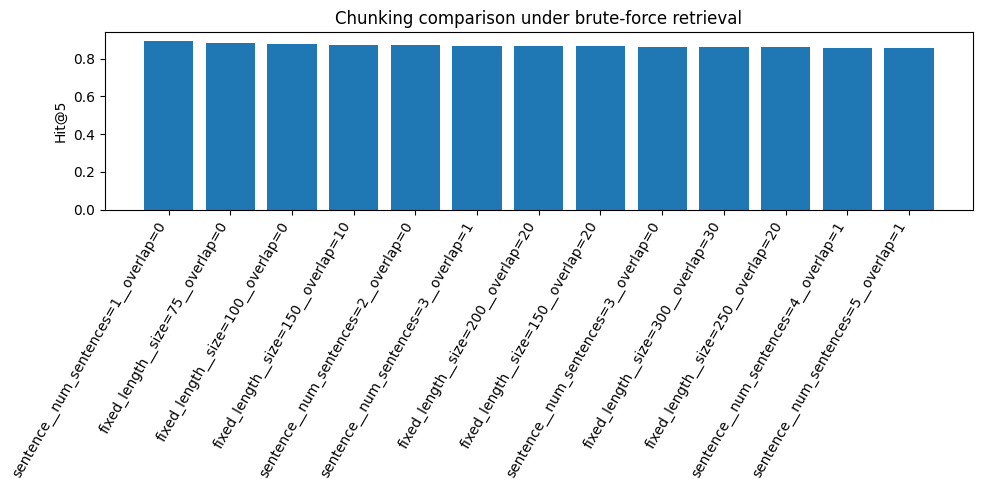

In [27]:

plt.figure(figsize=(10, 5))
plot_df = chunking_results_df.copy()
plot_df = plot_df.sort_values(["Hit@5", "MRR"], ascending=False)

plt.bar(plot_df["label"], plot_df["Hit@5"])
plt.xticks(rotation=60, ha="right")
plt.ylabel("Hit@5")
plt.title("Chunking comparison under brute-force retrieval")
plt.tight_layout()
plt.show()

In [28]:
# Supplemental chunking diagnostics using the added metrics
chunking_diagnostic_cols = [
    "label",
    "strategy",
    "Hit@5",
    "Precision@5",
    "MAP@10",
    "AnswerRecall@5",
    "MRR",
    "nDCG@10",
    "mean_query_time_sec",
    "build_time_sec",
]
available_chunking_cols = [col for col in chunking_diagnostic_cols if col in chunking_results_df.columns]
display(chunking_results_df[available_chunking_cols])


,label,strategy,Hit@5,Precision@5,MAP@10,AnswerRecall@5,MRR,nDCG@10,mean_query_time_sec,build_time_sec
7,sentence__num_sentences=1__overlap=0,sentence,0.894386,0.679924,0.587645,0.320238,0.861437,0.667397,0.005896,779.579118
0,fixed_length__size=75__overlap=0,fixed-length,0.881066,0.658421,0.567894,0.148810,0.811953,0.647481,0.008612,898.223327
1,fixed_length__size=100__overlap=0,fixed-length,0.878211,0.669267,0.576684,0.201190,0.824562,0.654877,0.008705,776.672233
2,fixed_length__size=150__overlap=10,fixed-length,0.870599,0.684110,0.594319,0.278571,0.822935,0.667258,0.005593,798.853463
8,sentence__num_sentences=2__overlap=0,sentence,0.869648,0.686013,0.600356,0.352381,0.833325,0.669645,0.003155,693.870832
9,sentence__num_sentences=3__overlap=1,sentence,0.868696,0.703140,0.618312,0.376190,0.820679,0.682638,0.003963,1038.860866
3,fixed_length__size=200__overlap=20,fixed-length,0.868696,0.683159,0.600354,0.321429,0.820568,0.669623,0.003737,851.970309
4,fixed_length__size=150__overlap=20,fixed-length,0.866794,0.679163,0.587162,0.275000,0.820723,0.662165,0.005427,887.958952
10,sentence__num_sentences=3__overlap=0,sentence,0.863939,0.682778,0.595985,0.379762,0.815696,0.664422,0.002692,664.800253
5,fixed_length__size=300__overlap=30,fixed-length,0.862036,0.685633,0.600271,0.357143,0.807312,0.666418,0.003757,766.490375


## Interpretation of chunking results

The chunking results show a consistent trade-off between retrieval sharpness, answer containment, and efficiency. In general, smaller chunks perform better on article-level ranking metrics such as ``Hit@1``, ``Hit@5``, ``MRR``, and `nDCG@10`, because they isolate narrower pieces of text and make it easier for the retriever to match the relevant article early in the ranked list. This is why the strongest performance comes from sentence chunking with 1 sentence and no overlap, which achieves the best  metric scores: ``Hit@1`` (0.838), ``Hit@5`` (0.894), ``MRR`` (0.861), and ``nDCG@10`` (0.667) across all tested settings.

At the same time, the table also shows that very small chunks are not always best for downstream QA readiness. Although 1-sentence chunks rank the correct article very well, they have lower answer-bearing recall than larger chunks, because the answer may be split across neighboring chunks. As chunk size increases, ``AnswerRecall@5`` and ``AnswerRecall@10`` improve, especially for sentence chunking with overlap. The best answer-bearing results come from sentence chunking with 5 sentences and overlap 1, which reaches ``AnswerRecall@5 = 0.399`` and ``AnswerRecall@10 = 0.433``, the highest values in the table. This suggests that larger overlapping chunks are more likely to preserve the full evidence span needed for answer generation, even if they are slightly weaker at ranking the correct article at the very top.

The fixed-length results follow the same pattern. Among the fixed-length strategies, chunk size 100 with overlap 0 reachs the highest scores (``Hit@5`` (0.878), ``MRR`` (0.825), and ``nDCG@10`` (0.655)) in that family, but it is still slightly weaker than the best sentence-based configuration.

Efficiency also changes with chunking. Configurations that create more chunks are slower because the retriever searches a larger index. Larger chunks reduce the number of indexed units and therefore improve throughput, but this speed gain comes with some loss in early-ranking accuracy.

That said, although a chunking strategy of 1 sentence with no overlap gives the strongest pure retrieval scores, it is also the most aggressive chunking strategy: it produces many very small chunks and tends to break information into narrow pieces. That helps the retriever identify the correct article early, but it also increases the chance that the evidence needed to answer the question is split across neighboring chunks. In contrast, 3 sentences with overlap 1 is a better balanced chunking strategy. It still performs strongly on the main retrieval metrics, ``with Hit@5 = 0.869``, which is only slightly below the best value of ``0.894``, but it does a better job of preserving usable context. Its ``AnswerRecall@5 = 0.376`` and ``AnswerRecall@10 = 0.421`` are clearly higher than the 1-sentence setting, which means the retrieved chunks are more likely to actually contain the answer text. This makes it more suitable for downstream QA, where retrieving the right article is not enough: the retrieved chunk also needs to contain enough evidence to support generation.

Therefore, 3 sentences with overlap 1 offers a practical middle ground: it creates far fewer chunks than the 1-sentence strategy, so the search space is smaller and the system remains fast, while still avoiding the much broader, noisier chunks produced by 4- or 5-sentence settings. Concretely,

* it keeps retrieval quality high,
* it improves the chance that retrieved chunks contain complete answer evidence,
* and it does so without the very large index size created by the smallest chunking strategies

The strategy sacrifices a small amount of top-rank retrieval accuracy compared with 1-sentence chunks, but gains a more useful and stable context unit for downstream question answering. 


## Shortcomings of the chunking evaluation design

This evaluation protocol is useful, but it has several limitations that should be acknowledged explicitly.

1. **All chunks from the correct article are treated as relevant.**  A chunk is marked positive if it comes from the source article, even if it does not actually contain the answer.

2. **Chunk size changes the number of positives.** A smaller chunking strategy typically creates more chunks per article, which changes the number of relevant items for a question.

3. **Overlap can create near-duplicate positives.** Overlapping chunks can make the ranking look stronger because many nearly identical chunks from the same article count as relevant.

4. **This is retrieval-only, not end-to-end QA evaluation.** A chunking strategy may score well here but still provide weak context for answer generation.

In [29]:
# Choose the chunking strategy to carry forward

print("Selected chunking configuration:")

SELECTED_CHUNKING = {
    "strategy": "sentence",
    "parameters": {
        "num_sentences": 3,
        "overlap_size": 1,
    },
}

selected_row = chunking_results_df[
    (chunking_results_df["strategy"] == SELECTED_CHUNKING["strategy"]) &
    (chunking_results_df["parameters"].apply(
        lambda x: x.get("num_sentences") == SELECTED_CHUNKING["parameters"]["num_sentences"]
        and x.get("overlap_size") == SELECTED_CHUNKING["parameters"]["overlap_size"]
    ))
].iloc[0]

display(selected_row.to_frame().T)
print(SELECTED_CHUNKING)

Selected chunking configuration:


,label,strategy,parameters,num_chunks,mean_chunk_length_chars,build_time_sec,Hit@1,Recall@1,Precision@1,MAP@1,...,AnswerRecall@10,MRR,nDCG@10,ANNRecall@1,ANNRecall@3,ANNRecall@5,ANNRecall@10,mean_query_time_sec,p95_query_time_sec,throughput_qps
9,sentence__num_sentences=3__overlap=1,sentence,"{'num_sentences': 3, 'overlap_size': 1}",17161,376.013461,1038.860866,0.784967,0.009624,0.784967,0.784967,...,0.421429,0.820679,0.682638,1.0,1.0,1.0,1.0,0.003963,0.004939,252.365646


{'strategy': 'sentence', 'parameters': {'num_sentences': 3, 'overlap_size': 1}}


# Part B: Compare Brute Force, HNSW, and LSH

This section shifts the focus from what is being retrieved to how retrieval is executed. After Part A selects a chunking strategy, that chunking configuration is held fixed so that the only changing component is the indexing backend. In this part, the notebook therefore compares three alternative ways of searching the same embedding space over the same chunk set: exact brute-force search, HNSW approximate nearest-neighbor search, and LSH-based approximate search.

Conceptually, these backends represent different tradeoffs between accuracy, speed, and memory use. Brute-force search serves as the exact reference because it compares each query embedding against all chunk embeddings directly. HNSW and LSH, by contrast, are approximate methods: they aim to return good neighbors much faster, but they may fail to reproduce the exact top results. That means this section is not only about retrieval quality in the usual sense, but also about systems performance. The comparison asks: how much retrieval quality is preserved when the system moves from exact search to a more scalable ANN backend, and what is gained in return in terms of latency, throughput, and index size?

To answer that, we evaluate each backend under the same relevance framework used earlier, while also adding backend-specific diagnostics. Standard retrieval metrics such as `Hit@k`, `MRR`, `nDCG@10`, `Precision@k`, and answer-bearing `AnswerRecall@k` show whether the backend still captures useful chunks. At the same time, index-level diagnostics such as build time, memory footprint, p95 latency, throughput, and `ANNRecall@k` relative to brute force show whether the approximate methods remain close enough to the exact reference to justify their speed advantages. So in Part B we move from purely retrieval-quality analysis to a more realistic engineering comparison of search infrastructure.

In [30]:
SELECTED_CHUNKING = {
    "strategy": "sentence",
    "parameters": {
        "num_sentences": 3,
        "overlap_size": 1,
    },
}

# Build the final chunk table and embeddings using the selected chunking strategy
selected_chunk_df = build_chunk_table(
    corpus_paths=corpus_files,
    strategy=SELECTED_CHUNKING["strategy"],
    parameters=SELECTED_CHUNKING["parameters"],
    processor=processor,
)
selected_chunk_embeddings = attach_embeddings(selected_chunk_df, embedder)

print("Selected chunking strategy:", SELECTED_CHUNKING)
print("Final chunk count:", len(selected_chunk_df))
print("Embedding matrix shape:", selected_chunk_embeddings.shape)

Selected chunking strategy: {'strategy': 'sentence', 'parameters': {'num_sentences': 3, 'overlap_size': 1}}
Final chunk count: 17161
Embedding matrix shape: (17161, 384)


In [31]:
# Index builders
def build_hnsw_index(embeddings: np.ndarray, chunk_df: pd.DataFrame, **kwargs):
    index = FaissHNSW(dim=embeddings.shape[1], **kwargs)
    metadata = chunk_df["chunk_id"].tolist()
    index.add_embeddings(embeddings, metadata)
    return index


def build_lsh_index(embeddings: np.ndarray, chunk_df: pd.DataFrame, **kwargs):
    index = FaissLSH(dim=embeddings.shape[1], **kwargs)
    metadata = chunk_df["chunk_id"].tolist()
    index.add_embeddings(embeddings, metadata)
    return index


In [32]:
# Brute-force baseline on the selected chunking
index_comparison_results = []

t0 = time.perf_counter()
bruteforce_index = build_bruteforce_index(selected_chunk_embeddings)
build_time = time.perf_counter() - t0
index_size_bytes = estimate_index_size_bytes(bruteforce_index)

_, summary = evaluate_retrieval_backend(
    questions=questions_with_embeddings,
    chunk_df=selected_chunk_df,
    backend_name="bruteforce",
    backend_obj=bruteforce_index,
    top_k=max(TOP_K_VALUES),
    reference_backend_obj=bruteforce_index,
    reference_backend_name="bruteforce",
)

index_comparison_results.append(
    {
        "index_type": "bruteforce",
        "parameters": {"metric": "L2"},
        "build_time_sec": build_time,
        "index_size_bytes": index_size_bytes,
        "index_size_mb": (index_size_bytes / (1024 ** 2)) if index_size_bytes is not None else np.nan,
        **summary,
    }
)


In [33]:
# HNSW runs
for cfg in HNSW_CONFIGS:
    print("Running HNSW config:", cfg)
    t0 = time.perf_counter()
    hnsw_index = build_hnsw_index(selected_chunk_embeddings, selected_chunk_df, **cfg)
    build_time = time.perf_counter() - t0
    index_size_bytes = estimate_index_size_bytes(hnsw_index)

    _, summary = evaluate_retrieval_backend(
        questions=questions_with_embeddings,
        chunk_df=selected_chunk_df,
        backend_name="hnsw",
        backend_obj=hnsw_index,
        top_k=max(TOP_K_VALUES),
        reference_backend_obj=bruteforce_index,
        reference_backend_name="bruteforce",
    )

    index_comparison_results.append(
        {
            "index_type": "hnsw",
            "parameters": cfg,
            "build_time_sec": build_time,
            "index_size_bytes": index_size_bytes,
            "index_size_mb": (index_size_bytes / (1024 ** 2)) if index_size_bytes is not None else np.nan,
            **summary,
        }
    )


Running HNSW config: {'M': 16, 'efConstruction': 40, 'metric': 'euclidean'}
Running HNSW config: {'M': 16, 'efConstruction': 80, 'metric': 'euclidean'}
Running HNSW config: {'M': 32, 'efConstruction': 80, 'metric': 'euclidean'}
Running HNSW config: {'M': 32, 'efConstruction': 120, 'metric': 'euclidean'}


In [34]:
# LSH runs
for cfg in LSH_CONFIGS:
    print("Running LSH config:", cfg)
    t0 = time.perf_counter()
    lsh_index = build_lsh_index(selected_chunk_embeddings, selected_chunk_df, **cfg)
    build_time = time.perf_counter() - t0
    index_size_bytes = estimate_index_size_bytes(lsh_index)

    _, summary = evaluate_retrieval_backend(
        questions=questions_with_embeddings,
        chunk_df=selected_chunk_df,
        backend_name="lsh",
        backend_obj=lsh_index,
        top_k=max(TOP_K_VALUES),
        reference_backend_obj=bruteforce_index,
        reference_backend_name="bruteforce",
    )

    index_comparison_results.append(
        {
            "index_type": "lsh",
            "parameters": cfg,
            "build_time_sec": build_time,
            "index_size_bytes": index_size_bytes,
            "index_size_mb": (index_size_bytes / (1024 ** 2)) if index_size_bytes is not None else np.nan,
            **summary,
        }
    )


Running LSH config: {'nbits': 64}
Running LSH config: {'nbits': 128}
Running LSH config: {'nbits': 256}


In [35]:

index_results_df = pd.DataFrame(index_comparison_results).sort_values(
    ["Hit@5", "MRR"], ascending=False
)

index_results_path = RESULTS_DIR / "task1_index_results.csv"
index_results_df.to_csv(index_results_path, index=False)

print("Saved index results to:", index_results_path)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", None,
    "display.width", None
):
    display(index_results_df)

Saved index results to: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results\task1_index_results.csv


,index_type,parameters,build_time_sec,index_size_bytes,index_size_mb,Hit@1,Recall@1,Precision@1,MAP@1,AnswerRecall@1,Hit@3,Recall@3,Precision@3,MAP@3,AnswerRecall@3,Hit@5,Recall@5,Precision@5,MAP@5,AnswerRecall@5,Hit@10,Recall@10,Precision@10,MAP@10,AnswerRecall@10,MRR,nDCG@10,ANNRecall@1,ANNRecall@3,ANNRecall@5,ANNRecall@10,mean_query_time_sec,p95_query_time_sec,throughput_qps
0,bruteforce,{'metric': 'L2'},0.010413,26359341,25.138227,0.784967,0.009624,0.784967,0.784967,0.255952,0.854424,0.024193,0.732636,0.714346,0.330952,0.868696,0.038274,0.703140,0.675373,0.376190,0.885823,0.070496,0.656137,0.618312,0.421429,0.820679,0.682638,1.000000,1.000000,1.000000,1.000000,0.003212,0.003904,311.311459
4,hnsw,"{'M': 32, 'efConstruction': 120, 'metric': 'euclidean'}",1.696642,31030606,29.593092,0.777355,0.009529,0.777355,0.777355,0.253571,0.842055,0.023864,0.726292,0.708743,0.328571,0.853473,0.037921,0.698763,0.672515,0.370238,0.864891,0.070278,0.654900,0.619077,0.410714,0.809583,0.679901,0.964795,0.970504,0.967460,0.955852,0.001344,0.002420,744.055889
3,hnsw,"{'M': 32, 'efConstruction': 80, 'metric': 'euclidean'}",1.051318,31030606,29.593092,0.774500,0.009488,0.774500,0.774500,0.252381,0.840152,0.024057,0.727561,0.709959,0.327381,0.849667,0.038060,0.698953,0.673206,0.370238,0.862036,0.070434,0.654710,0.618819,0.409524,0.806943,0.679596,0.964795,0.955281,0.956232,0.947764,0.001361,0.001771,735.023014
2,hnsw,"{'M': 16, 'efConstruction': 80, 'metric': 'euclidean'}",1.114078,28834342,27.498571,0.768792,0.009451,0.768792,0.768792,0.251190,0.828735,0.023848,0.720901,0.704250,0.328571,0.842055,0.037874,0.694957,0.669115,0.369048,0.857279,0.070042,0.653758,0.617708,0.407143,0.799865,0.677108,0.957184,0.960990,0.951855,0.941294,0.001574,0.002821,635.414779
7,lsh,{'nbits': 256},0.131185,942461,0.898801,0.740247,0.009156,0.740247,0.740247,0.201190,0.820171,0.022922,0.684110,0.660799,0.290476,0.839201,0.035206,0.648906,0.614158,0.338095,0.862988,0.062882,0.594957,0.545543,0.391667,0.783001,0.624716,0.506185,0.525531,0.521028,0.518363,0.010490,0.019492,95.333001
1,hnsw,"{'M': 16, 'efConstruction': 40, 'metric': 'euclidean'}",0.663659,28834342,27.498571,0.756422,0.009005,0.756422,0.756422,0.250000,0.817317,0.023041,0.709800,0.693731,0.325000,0.825880,0.036862,0.686394,0.661748,0.363095,0.835395,0.068634,0.648335,0.613887,0.407143,0.787323,0.670300,0.938154,0.943546,0.931494,0.914938,0.001389,0.002539,720.146387
6,lsh,{'nbits': 128},0.157862,471277,0.449445,0.673644,0.007992,0.673644,0.673644,0.178571,0.779258,0.019443,0.614970,0.584523,0.264286,0.804948,0.029580,0.575071,0.533549,0.298810,0.842055,0.051590,0.523501,0.461707,0.350000,0.732326,0.553425,0.320647,0.353949,0.352617,0.343007,0.012569,0.025804,79.560535
5,lsh,{'nbits': 64},0.076743,235685,0.224767,0.543292,0.006517,0.543292,0.543292,0.123810,0.679353,0.015211,0.464954,0.425468,0.201190,0.718363,0.021522,0.417888,0.364833,0.247619,0.768792,0.035040,0.359562,0.286743,0.302381,0.622016,0.395053,0.190295,0.203933,0.211227,0.209420,0.008714,0.014486,114.761806


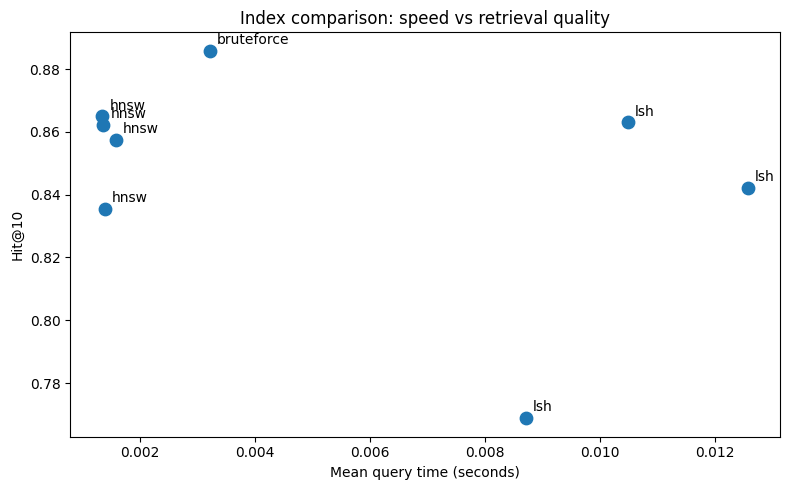

In [36]:

plt.figure(figsize=(8, 5))
plt.scatter(index_results_df["mean_query_time_sec"], index_results_df["Hit@10"], s=80)

for _, row in index_results_df.iterrows():
    plt.annotate(
        row["index_type"],
        (row["mean_query_time_sec"], row["Hit@10"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Mean query time (seconds)")
plt.ylabel("Hit@10")
plt.title("Index comparison: speed vs retrieval quality")
plt.tight_layout()
plt.show()

,index_type,parameters,Hit@5,Precision@5,MAP@10,AnswerRecall@5,ANNRecall@10,mean_query_time_sec,p95_query_time_sec,throughput_qps,index_size_mb,build_time_sec
0,bruteforce,{'metric': 'L2'},0.868696,0.703140,0.618312,0.376190,1.000000,0.003212,0.003904,311.311459,25.138227,0.010413
4,hnsw,"{'M': 32, 'efConstruction': 120, 'metric': 'eu...",0.853473,0.698763,0.619077,0.370238,0.955852,0.001344,0.002420,744.055889,29.593092,1.696642
3,hnsw,"{'M': 32, 'efConstruction': 80, 'metric': 'euc...",0.849667,0.698953,0.618819,0.370238,0.947764,0.001361,0.001771,735.023014,29.593092,1.051318
2,hnsw,"{'M': 16, 'efConstruction': 80, 'metric': 'euc...",0.842055,0.694957,0.617708,0.369048,0.941294,0.001574,0.002821,635.414779,27.498571,1.114078
7,lsh,{'nbits': 256},0.839201,0.648906,0.545543,0.338095,0.518363,0.010490,0.019492,95.333001,0.898801,0.131185
1,hnsw,"{'M': 16, 'efConstruction': 40, 'metric': 'euc...",0.825880,0.686394,0.613887,0.363095,0.914938,0.001389,0.002539,720.146387,27.498571,0.663659
6,lsh,{'nbits': 128},0.804948,0.575071,0.461707,0.298810,0.343007,0.012569,0.025804,79.560535,0.449445,0.157862
5,lsh,{'nbits': 64},0.718363,0.417888,0.286743,0.247619,0.209420,0.008714,0.014486,114.761806,0.224767,0.076743


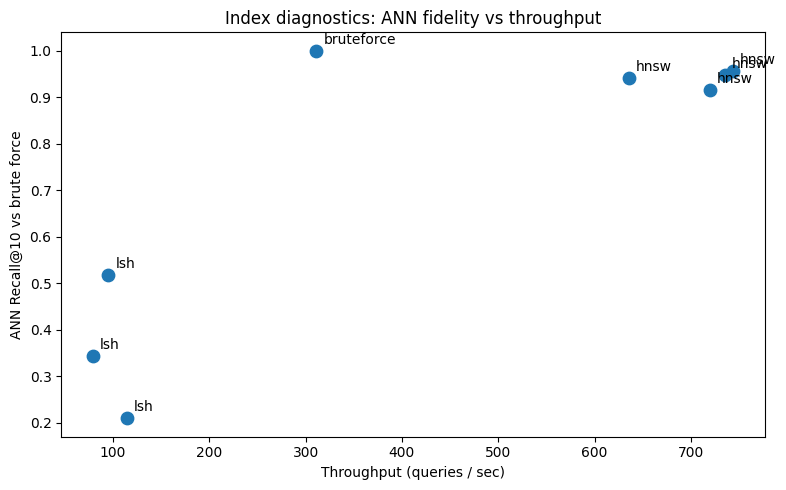

In [37]:
# Supplemental index diagnostics
index_diagnostic_cols = [
    "index_type",
    "parameters",
    "Hit@5",
    "Precision@5",
    "MAP@10",
    "AnswerRecall@5",
    "ANNRecall@10",
    "mean_query_time_sec",
    "p95_query_time_sec",
    "throughput_qps",
    "index_size_mb",
    "build_time_sec",
]
available_index_cols = [col for col in index_diagnostic_cols if col in index_results_df.columns]
display(index_results_df[available_index_cols])

plt.figure(figsize=(8, 5))
plot_df = index_results_df.sort_values(["ANNRecall@10", "throughput_qps"], ascending=False)
plt.scatter(plot_df["throughput_qps"], plot_df["ANNRecall@10"], s=80)
for _, row in plot_df.iterrows():
    plt.annotate(
        row["index_type"],
        (row["throughput_qps"], row["ANNRecall@10"]),
        xytext=(5, 5),
        textcoords="offset points",
    )
plt.xlabel("Throughput (queries / sec)")
plt.ylabel("ANN Recall@10 vs brute force")
plt.title("Index diagnostics: ANN fidelity vs throughput")
plt.tight_layout()
plt.show()


## Interpretation of indexing results

The index comparison shows that brute force remains the strongest option in terms of retrieval effectiveness. It achieves the highest values on the most important quality metrics, including Hit@5, MRR, nDCG@10, and AnswerRecall@5/10. This means it is the most reliable strategy for placing relevant chunks near the top of the ranking and for retrieving chunks that actually contain the answer text. Because brute force performs exact nearest-neighbor search, it also serves as the reference method with perfect ANN recall. Among the approximate methods, HNSW is clearly the strongest family. The best HNSW setting in this table is `M=32`, `efConstruction=120`, `metric='euclidean'`. This configuration comes very close to brute force on the main retrieval metrics, while being substantially faster at query time. In other words, HNSW preserves most of the quality of exact search while offering much better efficiency. This makes it the most attractive approximate retrieval strategy in the comparison and a strong practical compromise when speed matters. By contrast, LSH performs noticeably worse. Although it has smaller index sizes and low build times, its retrieval quality drops much more sharply, both on article-level metrics and on answer-bearing recall. Its ANN recall is also much lower, showing that it deviates more from the exact brute-force neighborhood structure. As a result, LSH is less suitable when retrieval quality is an important priority.

The best strategy therefore depends on the goal of the system. If the objective is to maximize retrieval quality on this dataset, then brute force is the best choice. However, if the goal is to balance retrieval quality with speed, then HNSW with `M=32` and `efConstruction=120` is the strongest option. It sacrifices only a small amount of accuracy while providing a large gain in throughput, so it remains the best speed–accuracy trade-off in the table.

In [46]:

# Save summary tables separately for easy reuse in the final report
chunking_results_df.to_csv(RESULTS_DIR / "task1_chunking_results_summary.csv", index=False)
index_results_df.to_csv(RESULTS_DIR / "task1_index_results_summary.csv", index=False)
reranker_results_df.to_csv(RESULTS_DIR / "task1_reranker_results_summary.csv", index=False)

print("All summary tables saved in:", RESULTS_DIR)

All summary tables saved in: C:\Users\Usuario\Downloads\textwave-hortner87-main(1)\textwave-hortner87-main\analysis\results
